In [2]:
from ref import *
from read_complex_matrix import read_complex_matrix
matr = read_complex_matrix('ref_matrix.txt')
import timeit

In [3]:
%%time

x_crit, x_max, y_max, x_min, y_min = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])

CPU times: total: 15.6 ms
Wall time: 3 ms


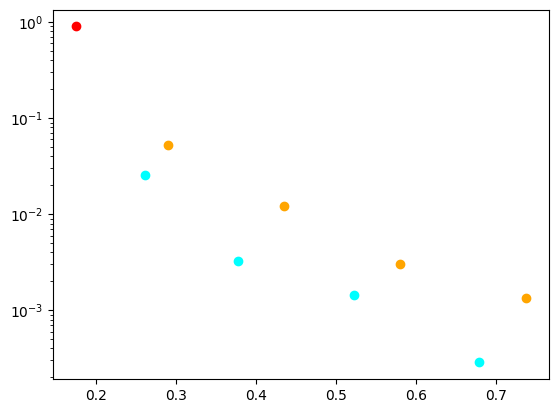

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

#ax.plot(q[0:len(y)]*1e-9, y)
ax.scatter(x_max*1e-9, y_max, color = 'orange')
ax.scatter(x_min*1e-9, y_min, color = 'cyan')
ax.scatter(x_crit*1e-9, 0.9, color = 'red')

ax.set_yscale('log')

plt.show()

In [5]:
def loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2):
    #r_min могут плохо сходиться в случаях со свёрткой, т.к. она их завышает на порядок
    return (2*(crit1-crit2)/crit1)**2 + np.sum(((r_max1-r_max2)/r_max1)**2) + np.sum(((q_max1-q_max2)/q_max1)**2) + np.sum(((q_min1-q_min2)/q_min1)**2)

In [6]:
original_trace = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])
#crit2, r_max2, q_max2, r_min2, q_min2 = original_trace

def objective_function(params, original_trace):
    rough1, len1, rough2, len2 = params
    crit2, r_max2, q_max2, r_min2, q_min2 = original_trace
    crit1, r_max1, q_max1, r_min1, q_min1 = reflectometry_trace(rough1, len1, rough2, len2)
    return 1e+6*loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2)

In [ ]:
class Comparator:
    def __init__(self, reference_points):
        self.reference_points = reference_points

    def compare(self, variable_points):
        for ref, var in zip(self.reference_points, variable_points):
            # сравнение
            pass

comparator = Comparator([(0, 0), (1, 1)])
# Вызываем compare много раз без повторной загрузки reference_points


In [7]:
from scipy.optimize import differential_evolution as de
from scipy.optimize import minimize


# диапазон для шероховатостей и глубин (для двух поверхностных слоёв)
bounds = [[1e-9, 9e-9], [3.e-08, 5.e-08],
          [1e-9, 9e-9], [1.4e-8, 2.6e-8]]

initial_guess = [4e-9, 3.1e-08, 2e-9, 1.5e-8]

In [8]:
%%time

# Оптимизация с симплекс-методом
result = minimize(
    objective_function,
    initial_guess,
    method='Nelder-Mead',  
    bounds=bounds
)

TypeError: objective_function() missing 1 required positional argument: 'original_trace'

In [9]:
result

NameError: name 'result' is not defined

In [15]:
%%time

# Оптимизация с автоматическим численным градиентом вариант 1
result = minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',  
    bounds=bounds,
    options={
        'eps': 1e-15, # Шаг для численного градиента
        'maxfun': 1e+8,
        'ftol': 2e-17, 
        'gtol': 1e-20
    }  
)

TypeError: objective_function() missing 1 required positional argument: 'original_trace'

In [ ]:
result

In [ ]:
%%time

# Оптимизация с автоматическим численным градиентом вариант 2
result = minimize(
    objective_function,
    initial_guess,
    method='TNC',  
    bounds=bounds,
    options={
        'eps': 1e-15, # Шаг для численного градиента
        'maxfun': 1e+8,
        'ftol': 2e-17, 
        'xtol': 1e-20,
        'gtol': 1e-20
            }
)

In [ ]:
result